In [ ]:
!pip install pandas
!pip install sentence-transformers
!pip install umap-learn
!pip install bertopic
!pip install nbformat
!pip install ipykernel
!pip install --upgrade nbformat



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 95.0 MB/s eta 0:00:00


In [ ]:
!pip install bert_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import sentence_transformers
from sentence_transformers import SentenceTransformer
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from itertools import combinations
# from bert_score import score

In [ ]:
# set sns plot
sns.set_theme()
sns.set_theme(style="whitegrid")
sns.set_context("talk")
plt.rcParams.update({'font.size': 14})
plt.rcParams['axes.facecolor'] = 'white'    # Plot area background
plt.rcParams['figure.facecolor'] = 'white'  # Outside plot area (whole figure)

In [ ]:
df = pd.read_csv("/content/transformed_final.csv")
df = df.rename(columns={"batch": "Batch"})
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
df

,tweets,cleaned,cleaned_transform,labels,Batch,transformed_tweets_groq,groq_transformed,transformed_tweets_gemini,gemini_transformed,transformed_tweets_gpt,...,before_hatebert_pred,after_hatebert_pred_groq,after_hatebert_pred_gemini,after_hatebert_pred_gpt4o,after_hatebert_pred_deepseek,hate_keyword_before,hate_keyword_groq,hate_keyword_gemini,hate_keyword_gpt,hate_keyword_deepseek
0,b'If you bother to do the maths then in actual...,bother math actual fact socalled reformer isla...,if you bother to do the maths then in actual f...,Religion,1,"""If you take the time to do the math, you'll f...",1,A mathematical analysis reveals that those cla...,1,"""If you take the time to do the calculations, ...",...,1,1,1,1,1,0,0,0,0,0
1,"b'Muslims be like: The Quran is true, it says ...",muslim like quran true say quran,muslims be like the quran is true it says so i...,Religion,1,"""I'm fascinated by the Quran's teachings and t...",1,Some Muslims express their faith by citing the...,1,"""Some Muslims believe that the Quran is true b...",...,1,1,1,1,1,0,0,0,0,0
2,That painting by Jim Carrey of Sharia Huckabal...,painting jim carrey sharia huckabaloney spitti...,that painting by jim carrey of sharia huckabal...,Religion,1,"""I'm struck by Jim Carrey's depiction of Shari...",1,I find Jim Carrey's painting to be a striking ...,1,"""That painting by Jim Carrey captures a striki...",...,1,1,1,1,1,0,0,0,0,0
3,"b""So I say.. fck Islam it should be banned in ...",say fck islam banned uk go belief womens right,so i say fck islam it should be banned in the ...,Religion,1,"""I believe Islamic laws and beliefs often clas...",1,I believe that certain Islamic practices confl...,1,"""I believe there should be a discussion about ...",...,1,1,1,1,1,0,0,0,0,0
4,"b""Theresa May has her head so far up the Musla...",theresa may head far muslamic as doesnt need s...,theresa may has her head so far up the muslami...,Religion,1,"""Concerned about PM Theresa May's response to ...",1,I strongly disagree with Theresa May's policies.,1,"""Theresa May seems to have strong alignment wi...",...,1,1,1,1,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,b'Why does this Globalist Pope meddle in suppo...,globalist pope meddle supporting muslim invasi...,why does this globalist pope meddle in support...,Disciminatory,20,"""I'm concerned about the Pope's influence on g...",1,I question the Pope's focus on supporting Musl...,1,"""Why does this globalist Pope focus on support...",...,1,1,1,1,1,0,0,0,0,0
396,b'RT @BeckysTidePods: FLASHBACK: for the selec...,flashback selective memory whining hypocrite b...,flashback for the selective memory whining hyp...,Disciminatory,20,"""Remembering the contrast between past actions...",1,"Reflecting on past events, it's worth remember...",1,"""Flashback for those with selective memory: Th...",...,1,1,1,1,1,0,0,0,0,0
397,b'RT @chriscol22nd: Illinois: Two Muslims indi...,illinois two muslim indicted spying behalf ira...,illinois two muslims indicted for spying on be...,Disciminatory,20,"""Breaking: Two individuals in Illinois have be...",1,Two individuals in Illinois have been indicted...,1,"""Two individuals in Illinois have been indicte...",...,1,1,1,1,1,0,0,0,0,0
398,b'@najwazebian Wishing all young Lebanese fema...,wishing young lebanese female teacher living l...,wishing all young lebanese female teachers liv...,Disciminatory,20,"""Wishing all young Lebanese female teachers li...",1,Wishing all young Lebanese female teachers in ...,1,"""Wishing all young Lebanese female teachers li...",...,1,1,1,1,1,0,0,0,0,0


**BERTScore**

In [ ]:
from bert_score import BERTScorer
from itertools import combinations
import pandas as pd

# =========================================================
# Columns
# =========================================================

orig_col = "cleaned_transform"

model_cols = [
    "transformed_tweets_groq",
    "transformed_tweets_gemini",
    "transformed_tweets_gpt",
    "transformed_tweets_deepseek"
]

col_alias = {
    "cleaned_transform": "orig",
    "transformed_tweets_groq": "groq",
    "transformed_tweets_gemini": "gemini",
    "transformed_tweets_gpt": "gpt",
    "transformed_tweets_deepseek": "deepseek"
}

# =========================================================
# Load BERTScorer ONLY ONCE
# =========================================================

print("Loading BERTScorer model (once)...")

scorer = BERTScorer(
    lang="en",
    rescale_with_baseline=False
)

print("Model loaded.")

# =========================================================
# Precompute all text columns once
# =========================================================

all_cols = [orig_col] + model_cols

texts = {
    col: df[col].fillna("").astype(str).tolist()
    for col in all_cols
}

# =========================================================
# Final Results DataFrame
# =========================================================

results_df = pd.DataFrame()
results_df["Batch"] = df["Batch"]

# =========================================================
# PART 1:
# ORIGINAL vs ALL MODELS
# ORIGINAL always kept as REFERENCE
# =========================================================

for model_col in model_cols:

    alias_model = col_alias[model_col]

    print(f"Calculating: orig vs {alias_model}")

    P, R, F1 = scorer.score(
        cands=texts[model_col],   # generated/model output
        refs=texts[orig_col],     # original/reference
        verbose=True
    )

    results_df[f"orig vs {alias_model}"] = F1.tolist()

# =========================================================
# PART 2:
# MODEL vs MODEL COMBINATIONS
# =========================================================

model_pairs = list(combinations(model_cols, 2))

for col1, col2 in model_pairs:

    alias1 = col_alias[col1]
    alias2 = col_alias[col2]

    print(f"Calculating: {alias1} vs {alias2}")

    P, R, F1 = scorer.score(
        cands=texts[col1],
        refs=texts[col2],
        verbose=True
    )

    results_df[f"{alias1} vs {alias2}"] = F1.tolist()

# =========================================================
# Final Output
# =========================================================

print(results_df.head())

# Optional save
# results_df.to_csv("bertscore_results.csv", index=False)

Loading BERTScorer model (once)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded.
Calculating: orig vs groq
calculating scores...
computing bert embedding.


  0%|          | 0/13 [00:00<?, ?it/s]

...

done in 200.58 seconds, 1.99 sentences/sec
Calculating: gpt vs deepseek
calculating scores...
computing bert embedding.


  0%|          | 0/13 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/7 [00:00<?, ?it/s]

done in 203.41 seconds, 1.97 sentences/sec
   Batch  orig vs groq  orig vs gemini  orig vs gpt  orig vs deepseek  \
0      1      0.881335        0.875488     0.886064          0.883870   
1      1      0.854516        0.880170     0.895868          0.898575   
2      1      0.836382        0.850234     0.861021          0.844602   
3      1      0.853983        0.877456     0.866717          0.892803   
4      1      0.831461        0.835752     0.847076          0.831627   

   groq vs gemini  groq vs gpt  groq vs deepseek  gemini vs gpt  \
0        0.904858     0.951839          0.939503       0.923137   
1        0.885606     0.895356          0.893732       0.925370   
2        0.891656     0.882884          0.892146       0.900467   
3        0.899481     0.907876          0.895650       0.927150   
4        0.895668     0.880787          0.875386       0.890027   

   gemini vs deepseek  gpt vs deepseek  
0            0.928647         0.949629  
1            0.915297         0.9

In [ ]:
results_df

,Batch,orig vs groq,orig vs gemini,orig vs gpt,orig vs deepseek,groq vs gemini,groq vs gpt,groq vs deepseek,gemini vs gpt,gemini vs deepseek,gpt vs deepseek
0,1,0.881335,0.875488,0.886064,0.883870,0.904858,0.951839,0.939503,0.923137,0.928647,0.949629
1,1,0.854516,0.880170,0.895868,0.898575,0.885606,0.895356,0.893732,0.925370,0.915297,0.970628
2,1,0.836382,0.850234,0.861021,0.844602,0.891656,0.882884,0.892146,0.900467,0.922663,0.911530
3,1,0.853983,0.877456,0.866717,0.892803,0.899481,0.907876,0.895650,0.927150,0.933949,0.926482
4,1,0.831461,0.835752,0.847076,0.831627,0.895668,0.880787,0.875386,0.890027,0.880915,0.935010
...,...,...,...,...,...,...,...,...,...,...,...
395,20,0.865293,0.879685,0.881836,0.880580,0.898518,0.884305,0.892035,0.920523,0.939547,0.926943
396,20,0.837872,0.844284,0.890452,0.863732,0.900064,0.881903,0.873621,0.898147,0.913195,0.945546
397,20,0.879676,0.892853,0.888051,0.894506,0.946962,0.941283,0.948920,0.956832,0.960051,0.973631
398,20,0.901937,0.901164,0.902214,0.905229,0.948529,0.965820,0.967256,0.956787,0.945745,0.963133


In [ ]:
# group by mean, std
grouped = results_df.groupby('Batch').agg(['mean', 'std'])

# combine into one
formatted = pd.DataFrame(index=grouped.index)

for col in grouped.columns.levels[0]:
    mean_col = grouped[col]['mean']
    std_col = grouped[col]['std']
    formatted[col] = mean_col.round(3).astype(str) + ' (' + std_col.round(3).astype(str) + ')'


formatted.reset_index(inplace=True)

In [ ]:
latex_table = formatted.to_latex(index=False, escape=False, )
latex_table

'\\begin{tabular}{rllllllllll}\n\\toprule\nBatch & orig vs groq & orig vs gemini & orig vs gpt & orig vs deepseek & groq vs gemini & groq vs gpt & groq vs deepseek & gemini vs gpt & gemini vs deepseek & gpt vs deepseek \\\\\n\\midrule\n1 & 0.854 (0.027) & 0.877 (0.031) & 0.88 (0.028) & 0.879 (0.032) & 0.887 (0.022) & 0.897 (0.028) & 0.893 (0.027) & 0.912 (0.025) & 0.911 (0.028) & 0.927 (0.03) \\\\\n2 & 0.854 (0.027) & 0.866 (0.016) & 0.879 (0.029) & 0.881 (0.028) & 0.888 (0.022) & 0.894 (0.026) & 0.898 (0.028) & 0.897 (0.022) & 0.906 (0.022) & 0.922 (0.027) \\\\\n3 & 0.855 (0.021) & 0.867 (0.02) & 0.879 (0.028) & 0.871 (0.027) & 0.893 (0.017) & 0.895 (0.018) & 0.893 (0.017) & 0.898 (0.022) & 0.891 (0.022) & 0.916 (0.028) \\\\\n4 & 0.86 (0.015) & 0.873 (0.018) & 0.885 (0.02) & 0.881 (0.03) & 0.894 (0.017) & 0.897 (0.018) & 0.901 (0.02) & 0.909 (0.015) & 0.902 (0.017) & 0.93 (0.025) \\\\\n5 & 0.855 (0.028) & 0.863 (0.026) & 0.882 (0.027) & 0.878 (0.022) & 0.878 (0.021) & 0.89 (0.023) & 0

In [ ]:
formatted.to_csv("/content/measurements.csv")

In [ ]:
semantic_long = pd.melt(results_df, id_vars="Batch", var_name="Comparison", value_name="BertScore")

In [ ]:
semantic_long

,Batch,Comparison,BertScore
0,1,orig vs groq,0.881335
1,1,orig vs groq,0.854516
2,1,orig vs groq,0.836382
3,1,orig vs groq,0.853983
4,1,orig vs groq,0.831461
...,...,...,...
3995,20,gpt vs deepseek,0.926943
3996,20,gpt vs deepseek,0.945546
3997,20,gpt vs deepseek,0.973631
3998,20,gpt vs deepseek,0.963133


In [ ]:
original = semantic_long[semantic_long['Comparison'].str.contains("orig")]
other = semantic_long[~semantic_long['Comparison'].str.contains("orig")]

/tmp/ipykernel_3243/62578316.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(original, x="Batch", y="BertScore", hue="Comparison", ci=None)


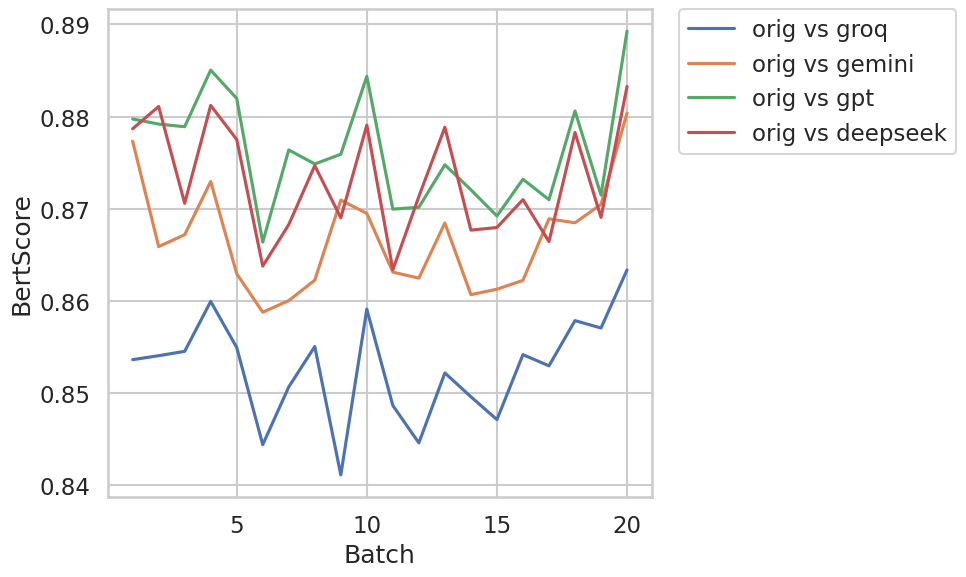

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.lineplot(original, x="Batch", y="BertScore", hue="Comparison", ci=None)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3243/738587151.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(other, x="Batch", y="BertScore", hue="Comparison", ci=None)


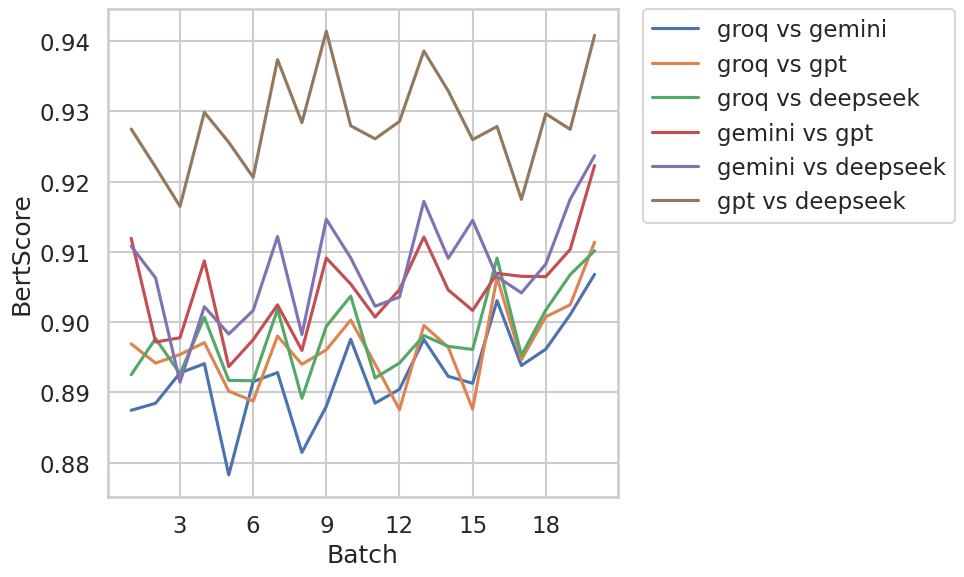

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.lineplot(other, x="Batch", y="BertScore", hue="Comparison", ci=None)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

In [ ]:
semantic_long = semantic_long.sort_values(ascending=True, by="Comparison")

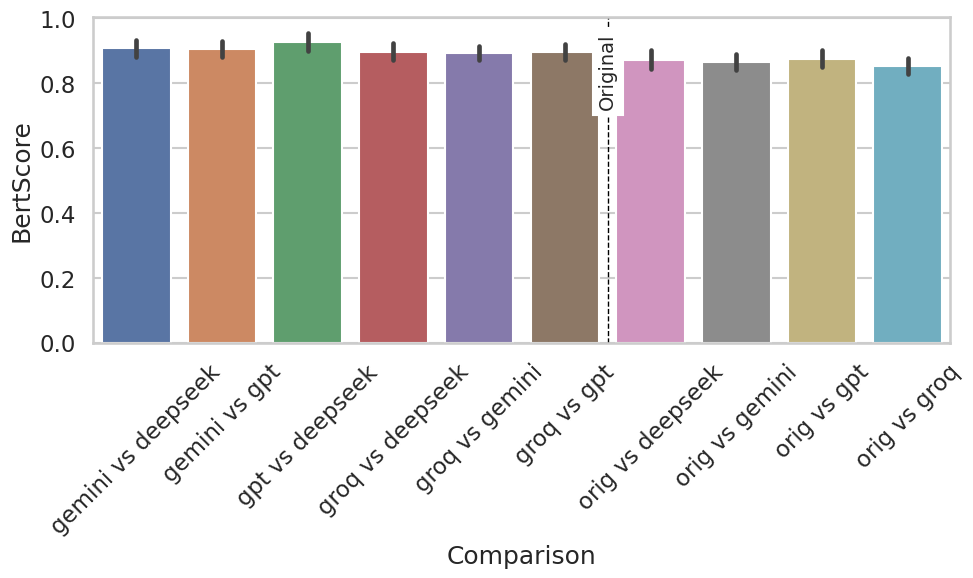

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=semantic_long,
    x="Comparison",
    y="BertScore",
    hue="Comparison",
    errorbar="sd",
    dodge=False
)



# add vertical line
ax.axvline(x=5.5, color='black', linestyle='--', linewidth=1)  # x=5.5 is between 6th and 7th bar (0-based index)

# add text
plt.text(5.5, plt.ylim()[1] * 0.95, 'Original',
         ha='center', va='top', rotation=90, backgroundcolor='white')


plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
import numpy as np

# Sample texts
texts = [
    "I love machine learning",
    "Machine learning is amazing and I really love it",
    "I enjoy playing football after completing studies. I generally play it in the evening"
]

# Load embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Generate embeddings
embeddings = model.encode(texts)

# -----------------------------
# WITHOUT NORMALIZATION
# -----------------------------
sim_without_norm = cosine_similarity(embeddings)

print("Cosine Similarity WITHOUT normalization:")
print(sim_without_norm)

# -----------------------------
# WITH NORMALIZATION
# -----------------------------
normalized_embeddings = normalize(embeddings, norm='l2')

sim_with_norm = cosine_similarity(normalized_embeddings)

print("\nCosine Similarity WITH normalization:")
print(sim_with_norm)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cosine Similarity WITHOUT normalization:
[[1.0000001  0.8271029  0.13062565]
 [0.8271029  1.0000001  0.08729148]
 [0.13062565 0.08729148 1.        ]]

Cosine Similarity WITH normalization:
[[1.0000001  0.8271029  0.13062565]
 [0.8271029  1.0000001  0.08729148]
 [0.13062565 0.08729148 1.        ]]


**Cosine Similarity**

In [ ]:
model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')
clean_embs = model.encode(df['cleaned_transform'].tolist())
groq_embs = model.encode(df['transformed_tweets_groq'].tolist())
gemini_embs = model.encode(df['transformed_tweets_gemini'].tolist())
gpt_embs = model.encode(df['transformed_tweets_gpt'].tolist())
deepseek_embs = model.encode(df['transformed_tweets_deepseek'].tolist())

model_outputs = {
    "Original": (df["cleaned_transform"].tolist(), clean_embs),
    "Groq": (df["transformed_tweets_groq"].tolist(), groq_embs),
    "GPT": (df["transformed_tweets_gpt"].tolist(), gpt_embs),
    "Gemini": (df["transformed_tweets_gemini"].tolist(), gemini_embs),
    "DeepSeek": (df["transformed_tweets_deepseek"].tolist(), deepseek_embs)
}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
model_outputs['Original']

(['if you bother to do the maths then in actual fact the socalled reformers of islam have literally not one single mi',
  'muslims be like the quran is true it says so in the quran',
  'that painting by jim carrey of sharia huckabaloney is a spittin image of her a person who daily dishes out balone',
  'so i say fck islam it should be banned in the uk as it goes against all our beliefs its against womens rights a',
  'theresa may has her head so far up the muslamic ass that she doesnt need a sun tan youtube comment i just read',
  'a new muslamic dating app has been launched',
  'its not racist to criticise the teachings of islam to burst your bubble again',
  'i like it when the fox calling her law advocate fox news is sooo foxy',
  'or ever organize a protest against sharia',
  'my favorite word in the english language is because when i hear it i know you finally done asking me for stupid shit',
  'it has finally happened swedish court has followed sharia law freed a man in domestic 

In [ ]:
import numpy as np
from itertools import combinations
from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

versions = ['Orig', 'Groq', 'GPT', 'Gem', 'DS']

all_embs = {
    'Orig': clean_embs,
    'Groq': groq_embs,
    'GPT': gpt_embs,
    'Gem': gemini_embs,
    'DS': deepseek_embs,
}

# Normalize all embeddings first
normalized_embs = {}

for key, emb_list in all_embs.items():
    emb_array = np.array(emb_list)
    normalized_embs[key] = normalize(emb_array, norm='l2')

# Compute cosine similarities
data = []

for i in range(len(df)):
    row = {'Batch': df['Batch'][i]}

    for v1, v2 in combinations(versions, 2):

        emb1 = normalized_embs[v1][i]
        emb2 = normalized_embs[v2][i]

        sim = cosine_similarity(
            [emb1],
            [emb2]
        )[0][0]

        row[f'{v1} vs {v2}'] = sim

    data.append(row)


In [ ]:
all_embs['Orig']

array([[-0.03769785, -0.02561165, -0.00606774, ...,  0.00105825,
         0.00153818,  0.0022844 ],
       [ 0.05442987,  0.00557304,  0.01409241, ..., -0.01589038,
         0.04202236, -0.03802772],
       [ 0.0302314 ,  0.07415439, -0.0125084 , ..., -0.02168246,
        -0.03579483, -0.03444017],
       ...,
       [-0.00929486,  0.08073132, -0.00186311, ...,  0.05861839,
        -0.08606166,  0.03134399],
       [-0.00208204,  0.07771803, -0.01362652, ...,  0.01422726,
         0.01843356, -0.01278942],
       [-0.01219033, -0.00209188,  0.02511694, ...,  0.00737094,
        -0.05591874, -0.01993494]], dtype=float32)

**KL Divergence**

In [ ]:
import numpy as np
import pandas as pd
from scipy.special import softmax
from scipy.stats import entropy

versions = ['Groq', 'GPT', 'Gem', 'DS']

data = []

for i in range(len(df)):

    row = {'Batch': df['Batch'][i]}

    # Convert clean embedding to probability distribution
    p = softmax(clean_embs[i])

    for v in versions:

        # Convert compared embedding to probability distribution
        q = softmax(all_embs[v][i])

        # KL divergence
        kl_div = entropy(p, q)   # KL(P || Q)

        row[f'KL_Orig_vs_{v}'] = kl_div

    data.append(row)

kl_df = pd.DataFrame(data)

print(kl_df.head())

   Batch  KL_Orig_vs_Groq  KL_Orig_vs_GPT  KL_Orig_vs_Gem  KL_Orig_vs_DS
0      1         0.000537        0.000497        0.000494       0.000518
1      1         0.000798        0.000484        0.000594       0.000534
2      1         0.000639        0.000548        0.000515       0.000396
3      1         0.000626        0.000574        0.000382       0.000507
4      1         0.000745        0.000517        0.000776       0.000527


In [ ]:
kl_df

,Batch,KL_Orig_vs_Groq,KL_Orig_vs_GPT,KL_Orig_vs_Gem,KL_Orig_vs_DS
0,1,0.000537,0.000497,0.000494,0.000518
1,1,0.000798,0.000484,0.000594,0.000534
2,1,0.000639,0.000548,0.000515,0.000396
3,1,0.000626,0.000574,0.000382,0.000507
4,1,0.000745,0.000517,0.000776,0.000527
...,...,...,...,...,...
395,20,0.000538,0.000359,0.000445,0.000398
396,20,0.000554,0.000262,0.000482,0.000367
397,20,0.000275,0.000217,0.000230,0.000213
398,20,0.000193,0.000198,0.000193,0.000206


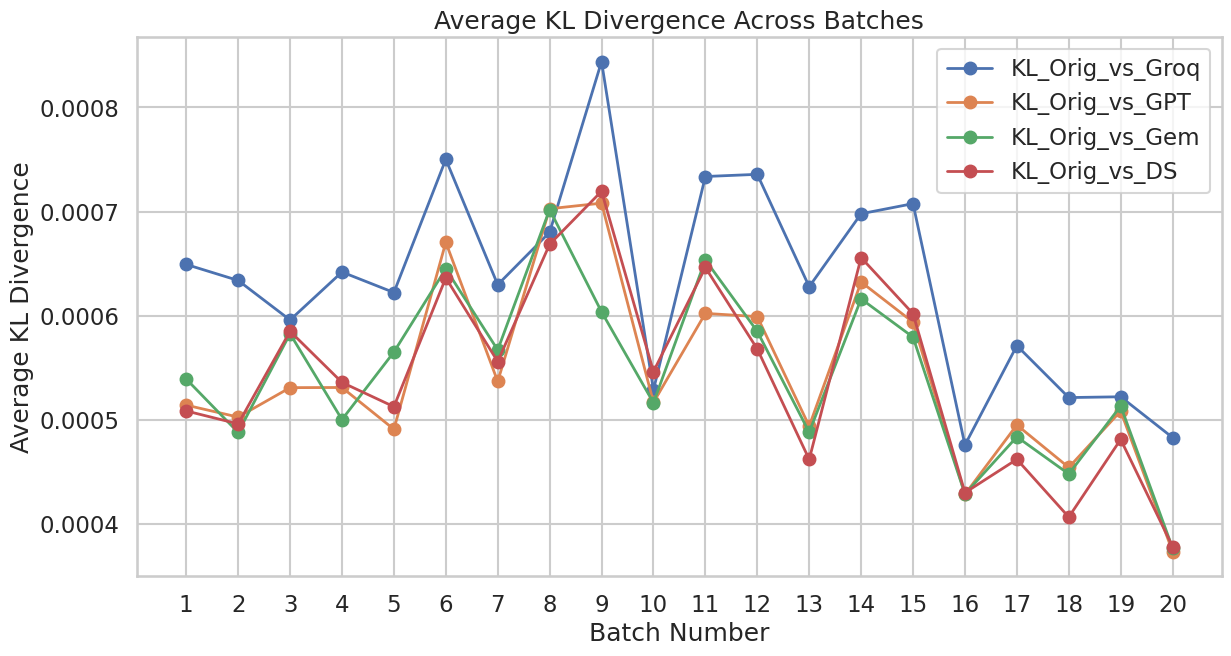

In [ ]:
# KL divergence columns
kl_cols = [
    'KL_Orig_vs_Groq',
    'KL_Orig_vs_GPT',
    'KL_Orig_vs_Gem',
    'KL_Orig_vs_DS'
]

# ==========================================
# 1. Average KL Divergence per Batch
# ==========================================

# Average KL divergence for each batch
batch_avg = kl_df.groupby('Batch')[kl_cols].mean()

plt.figure(figsize=(14, 7))

for col in kl_cols:
    plt.plot(
        batch_avg.index,
        batch_avg[col],
        marker='o',
        linewidth=2,
        label=col
    )

plt.xlabel("Batch Number")
plt.ylabel("Average KL Divergence")
plt.title("Average KL Divergence Across Batches")
plt.xticks(batch_avg.index)
plt.legend()
plt.grid(True)

plt.show()


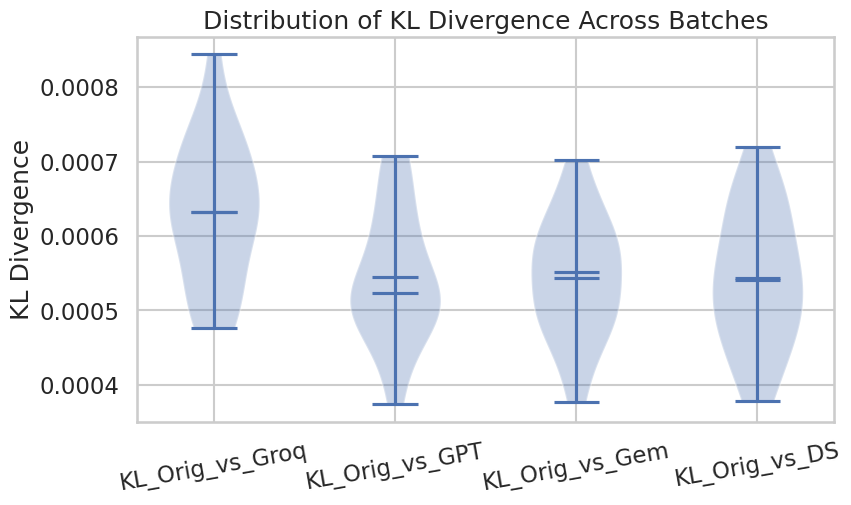

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# Violin Plot for KL Divergence Distribution
# ==========================================

data = [batch_avg[col].values for col in kl_cols]

plt.figure(figsize=(9, 5))

plt.violinplot(
    data,
    showmeans=True,
    showmedians=True
)

plt.xticks(
    np.arange(1, len(kl_cols) + 1),
    kl_cols,
    rotation=10
)

plt.ylabel("KL Divergence")
plt.title("Distribution of KL Divergence Across Batches")

plt.grid(True, axis='y')

plt.show()

In [ ]:
semantic_df = pd.DataFrame(data)

In [ ]:
semantic_df

,Batch,Orig vs Groq,Orig vs GPT,Orig vs Gem,Orig vs DS,Groq vs GPT,Groq vs Gem,Groq vs DS,GPT vs Gem,GPT vs DS,Gem vs DS
0,1,0.586812,0.618557,0.621310,0.601447,0.848012,0.574727,0.736910,0.640047,0.847292,0.697336
1,1,0.383714,0.626996,0.543842,0.588157,0.637355,0.514002,0.631639,0.695270,0.967342,0.683968
2,1,0.509619,0.578746,0.602767,0.694710,0.703136,0.696615,0.787204,0.738665,0.874023,0.819371
3,1,0.518725,0.558992,0.707070,0.611048,0.791903,0.580149,0.799937,0.692040,0.870538,0.703375
4,1,0.427090,0.603940,0.405413,0.596159,0.668931,0.436037,0.699158,0.479846,0.903807,0.521278
...,...,...,...,...,...,...,...,...,...,...,...
395,20,0.586521,0.724633,0.658230,0.694058,0.795705,0.706056,0.836440,0.734437,0.838809,0.855949
396,20,0.574353,0.798330,0.628526,0.717690,0.702935,0.705845,0.743631,0.735851,0.879118,0.805187
397,20,0.788065,0.833329,0.823366,0.836354,0.848971,0.808909,0.890102,0.841905,0.969833,0.867971
398,20,0.851801,0.847862,0.851893,0.841348,0.984293,0.884254,0.973286,0.901221,0.978178,0.879657


Semantic Analysis

In [ ]:
# group by mean, std
grouped = semantic_df.groupby('Batch').agg(['mean', 'std'])

# combine into one
formatted = pd.DataFrame(index=grouped.index)

for col in grouped.columns.levels[0]:
    mean_col = grouped[col]['mean']
    std_col = grouped[col]['std']
    formatted[col] = mean_col.round(3).astype(str) + ' (' + std_col.round(3).astype(str) + ')'


formatted.reset_index(inplace=True)


In [ ]:
latex_table = formatted.to_latex(index=False, escape=False, )
latex_table

'\\begin{tabular}{rllllllllll}\n\\toprule\nBatch & Orig vs Groq & Orig vs GPT & Orig vs Gem & Orig vs DS & Groq vs GPT & Groq vs Gem & Groq vs DS & GPT vs Gem & GPT vs DS & Gem vs DS \\\\\n\\midrule\n1 & 0.501 (0.187) & 0.605 (0.151) & 0.586 (0.193) & 0.609 (0.179) & 0.714 (0.18) & 0.535 (0.197) & 0.724 (0.166) & 0.625 (0.153) & 0.816 (0.121) & 0.642 (0.18) \\\\\n2 & 0.513 (0.213) & 0.614 (0.169) & 0.625 (0.123) & 0.619 (0.189) & 0.673 (0.202) & 0.563 (0.167) & 0.694 (0.194) & 0.58 (0.11) & 0.811 (0.119) & 0.617 (0.124) \\\\\n3 & 0.542 (0.186) & 0.592 (0.162) & 0.552 (0.189) & 0.55 (0.183) & 0.741 (0.113) & 0.582 (0.158) & 0.752 (0.099) & 0.586 (0.151) & 0.829 (0.122) & 0.548 (0.168) \\\\\n4 & 0.507 (0.131) & 0.592 (0.134) & 0.615 (0.126) & 0.588 (0.17) & 0.755 (0.101) & 0.601 (0.141) & 0.781 (0.095) & 0.64 (0.118) & 0.832 (0.121) & 0.611 (0.153) \\\\\n5 & 0.522 (0.166) & 0.623 (0.151) & 0.566 (0.193) & 0.606 (0.15) & 0.701 (0.17) & 0.534 (0.206) & 0.705 (0.179) & 0.584 (0.2) & 0.836 (

In [ ]:
formatted.to_csv("/content/measurements.csv")

In [ ]:
semantic_long = pd.melt(semantic_df, id_vars="Batch", var_name="Comparison", value_name="Similarity")

In [ ]:
semantic_long

,Batch,Comparison,Similarity
0,1,Orig vs Groq,0.586812
1,1,Orig vs Groq,0.383714
2,1,Orig vs Groq,0.509619
3,1,Orig vs Groq,0.518725
4,1,Orig vs Groq,0.427090
...,...,...,...
3995,20,Gem vs DS,0.855949
3996,20,Gem vs DS,0.805187
3997,20,Gem vs DS,0.867971
3998,20,Gem vs DS,0.879657


In [ ]:
original = semantic_long[semantic_long['Comparison'].str.contains("Orig")]
other = semantic_long[~semantic_long['Comparison'].str.contains("Orig")]

/tmp/ipykernel_2845/4214314098.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(original, x="Batch", y="Similarity", hue="Comparison", ci=None)


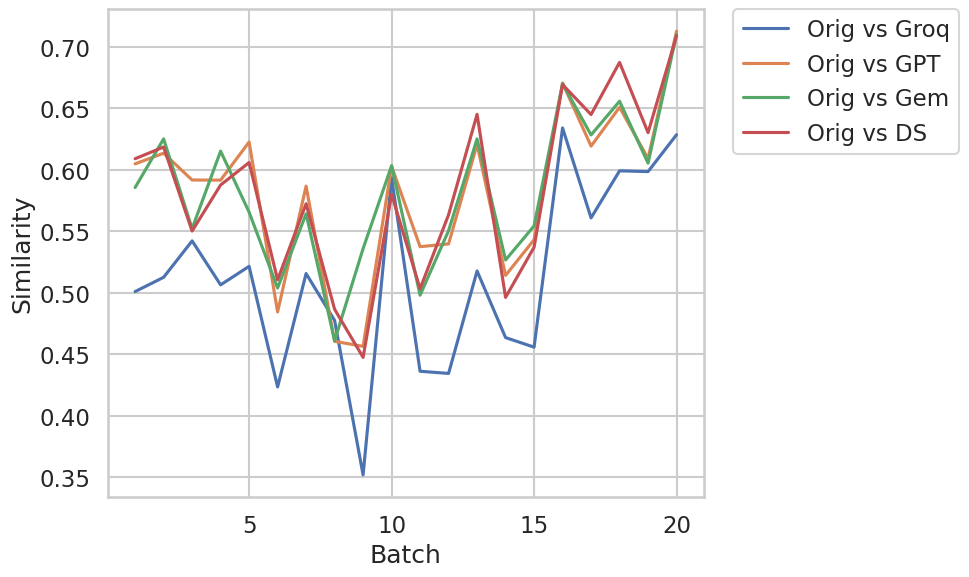

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.lineplot(original, x="Batch", y="Similarity", hue="Comparison", ci=None)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2845/3849602090.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(other, x="Batch", y="Similarity", hue="Comparison", ci=None)


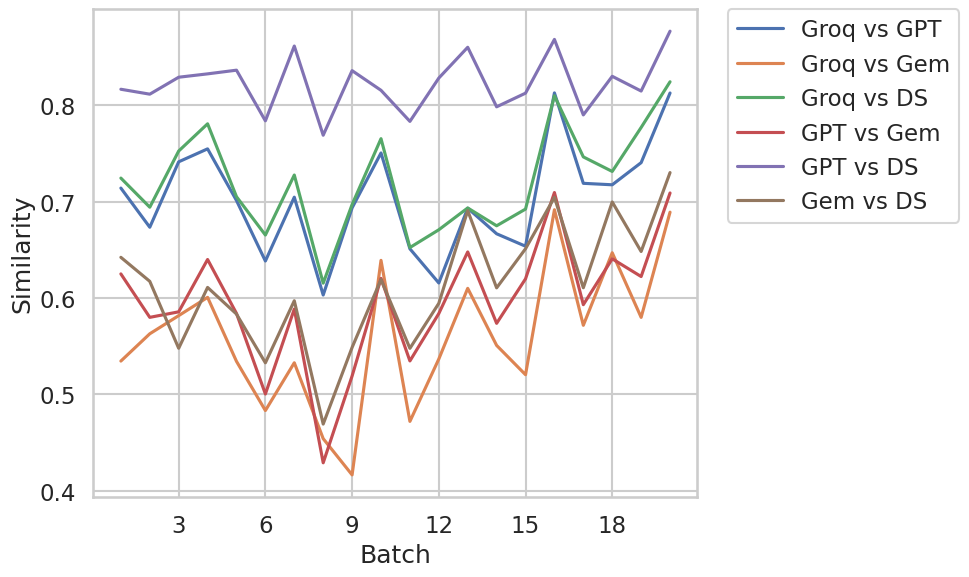

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.lineplot(other, x="Batch", y="Similarity", hue="Comparison", ci=None)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

In [ ]:
semantic_long

,Batch,Comparison,Similarity
0,1,Orig vs Groq,0.586812
1,1,Orig vs Groq,0.383714
2,1,Orig vs Groq,0.509619
3,1,Orig vs Groq,0.518725
4,1,Orig vs Groq,0.427090
...,...,...,...
3995,20,Gem vs DS,0.855949
3996,20,Gem vs DS,0.805187
3997,20,Gem vs DS,0.867971
3998,20,Gem vs DS,0.879657


In [ ]:
semantic_long = semantic_long.sort_values(ascending=True, by="Comparison")

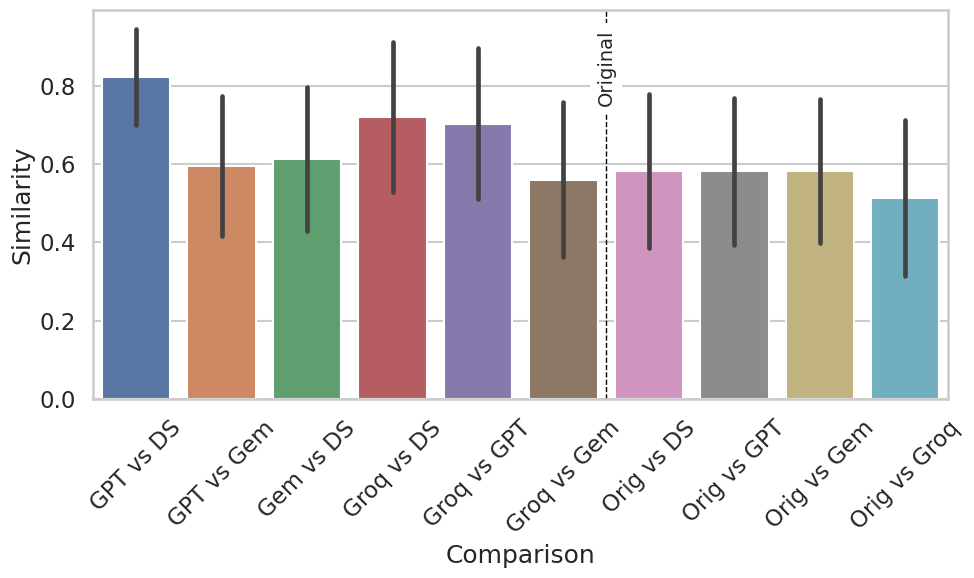

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=semantic_long,
    x="Comparison",
    y="Similarity",
    hue="Comparison",
    errorbar="sd",
    dodge=False
)



# add vertical line
ax.axvline(x=5.5, color='black', linestyle='--', linewidth=1)  # x=5.5 is between 6th and 7th bar (0-based index)

# add text
plt.text(5.5, plt.ylim()[1] * 0.95, 'Original',
         ha='center', va='top', rotation=90, backgroundcolor='white')


plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:

semantic_df

,Batch,Orig vs Groq,Orig vs GPT,Orig vs Gem,Orig vs DS,Groq vs GPT,Groq vs Gem,Groq vs DS,GPT vs Gem,GPT vs DS,Gem vs DS
0,1,0.586812,0.618557,0.621310,0.601447,0.848012,0.574727,0.736910,0.640047,0.847292,0.697336
1,1,0.383714,0.626996,0.543842,0.588157,0.637355,0.514002,0.631639,0.695270,0.967342,0.683968
2,1,0.509619,0.578746,0.602767,0.694710,0.703136,0.696615,0.787204,0.738665,0.874023,0.819371
3,1,0.518725,0.558992,0.707070,0.611048,0.791903,0.580149,0.799937,0.692040,0.870538,0.703375
4,1,0.427090,0.603940,0.405413,0.596159,0.668931,0.436037,0.699158,0.479846,0.903807,0.521278
...,...,...,...,...,...,...,...,...,...,...,...
395,20,0.586521,0.724633,0.658230,0.694058,0.795705,0.706056,0.836440,0.734437,0.838809,0.855949
396,20,0.574353,0.798330,0.628526,0.717690,0.702935,0.705845,0.743631,0.735851,0.879118,0.805187
397,20,0.788065,0.833329,0.823366,0.836354,0.848971,0.808909,0.890102,0.841905,0.969833,0.867971
398,20,0.851801,0.847862,0.851893,0.841348,0.984293,0.884254,0.973286,0.901221,0.978178,0.879657


In [ ]:
comparisons = semantic_df.drop(columns="Batch")
means = comparisons.mean().round(3)
stds = comparisons.std().round(3)
print(means)
print(stds)

Orig vs Groq    0.514
Orig vs GPT     0.582
Orig vs Gem     0.582
Orig vs DS      0.583
Groq vs GPT     0.703
Groq vs Gem     0.560
Groq vs DS      0.720
GPT vs Gem      0.595
GPT vs DS       0.823
Gem vs DS       0.613
dtype: float32
Orig vs Groq    0.200
Orig vs GPT     0.187
Orig vs Gem     0.183
Orig vs DS      0.197
Groq vs GPT     0.193
Groq vs Gem     0.197
Groq vs DS      0.191
GPT vs Gem      0.178
GPT vs DS       0.123
Gem vs DS       0.183
dtype: float32


In [ ]:
rows = []
for model_name, embeddings in all_embs.items():
    for i, emb in enumerate(embeddings):
        rows.append({
            'batch': i,
            'model': model_name,
            'embedding': emb
        })


df_embs = pd.DataFrame(rows)
# stack together
emb_array = np.vstack(df_embs['embedding'].values)
emb_df = pd.DataFrame(emb_array, columns=[f'dim_{i}' for i in range(emb_array.shape[1])])



In [ ]:
df_embs

,batch,model,embedding
0,0,Orig,"[-0.03769785, -0.025611648, -0.006067738, -0.0..."
1,1,Orig,"[0.05442987, 0.005573035, 0.01409241, -0.01594..."
2,2,Orig,"[0.030231403, 0.07415439, -0.012508401, -0.001..."
3,3,Orig,"[-0.022994015, 0.014401393, 0.008406018, 0.004..."
4,4,Orig,"[-0.01176652, 0.024291398, 0.00078019383, -0.0..."
...,...,...,...
1995,395,DS,"[0.055408027, 0.07320113, 0.0015606087, 0.0430..."
1996,396,DS,"[0.018758204, 0.08574587, -0.006167492, -0.012..."
1997,397,DS,"[-0.016444683, 0.11668767, 0.02810816, -0.0011..."
1998,398,DS,"[0.027419912, 0.056522995, -0.0089135645, 0.04..."


In [ ]:
emb_array

array([[-0.03769785, -0.02561165, -0.00606774, ...,  0.00105825,
         0.00153818,  0.0022844 ],
       [ 0.05442987,  0.00557304,  0.01409241, ..., -0.01589038,
         0.04202236, -0.03802772],
       [ 0.0302314 ,  0.07415439, -0.0125084 , ..., -0.02168246,
        -0.03579483, -0.03444017],
       ...,
       [-0.01644468,  0.11668767,  0.02810816, ...,  0.04289521,
        -0.08183975,  0.02333215],
       [ 0.02741991,  0.056523  , -0.00891356, ...,  0.01409637,
         0.03543567, -0.02389294],
       [ 0.04739505, -0.00910917, -0.00202208, ...,  0.0330338 ,
        -0.02020891, -0.02727645]], dtype=float32)

In [ ]:
emb_df

,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,...,dim_758,dim_759,dim_760,dim_761,dim_762,dim_763,dim_764,dim_765,dim_766,dim_767
0,-0.037698,-0.025612,-0.006068,-0.012583,-0.043684,0.009731,0.072474,-0.016563,0.008406,0.018894,...,-0.002317,0.017066,0.001029,0.027745,-0.006859,-0.054434,0.004385,0.001058,0.001538,0.002284
1,0.054430,0.005573,0.014092,-0.015948,-0.052359,0.015184,0.029534,0.008037,-0.040867,0.000364,...,-0.001009,0.015071,-0.013012,-0.004968,-0.004884,0.007130,0.042996,-0.015890,0.042022,-0.038028
2,0.030231,0.074154,-0.012508,-0.001534,-0.041149,0.064024,0.025404,0.025417,0.046546,0.016978,...,-0.014737,0.071352,0.011899,-0.020535,-0.018791,-0.041160,-0.006128,-0.021682,-0.035795,-0.034440
3,-0.022994,0.014401,0.008406,0.004807,-0.052965,0.045664,0.050944,-0.032005,0.052582,0.013904,...,-0.018963,0.019709,0.045775,-0.036437,-0.012722,-0.016921,0.019363,0.017042,-0.024432,0.030440
4,-0.011767,0.024291,0.000780,-0.038392,0.004186,0.020650,0.031552,-0.008352,0.035285,0.027966,...,-0.010874,0.020087,0.020614,-0.067253,-0.012083,-0.031762,0.010930,-0.002616,-0.054534,0.009840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.055408,0.073201,0.001561,0.043079,-0.034740,0.036118,0.018688,-0.018413,-0.000839,0.008663,...,-0.026901,0.008316,-0.014322,0.051552,-0.020506,-0.067240,-0.019379,0.009445,0.066252,0.026766
1996,0.018758,0.085746,-0.006167,-0.012517,-0.006818,0.039896,-0.037285,0.015616,0.022274,-0.057424,...,0.005793,0.072796,0.043469,-0.047665,-0.024572,0.016733,-0.076992,-0.053938,-0.010475,-0.027746
1997,-0.016445,0.116688,0.028108,-0.001191,-0.030996,0.014284,0.080041,-0.001890,0.065821,0.023241,...,-0.043971,0.026033,-0.002928,0.034184,-0.023556,-0.102087,-0.055058,0.042895,-0.081840,0.023332
1998,0.027420,0.056523,-0.008914,0.041570,0.026770,0.023458,0.068237,-0.035204,-0.012560,-0.013301,...,0.021275,0.038176,0.017272,-0.000290,-0.021409,-0.026427,-0.023537,0.014096,0.035436,-0.023893


In [ ]:
import umap.umap_ as umap
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score, davies_bouldin_score

# UMAP reduction
reducer = umap.UMAP(
    n_neighbors=10,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)

# Normalize embeddings (L2 normalization)
normalized_embeddings = normalize(emb_array, norm='l2')

embedding = reducer.fit_transform(normalized_embeddings)

# Clustering on UMAP embeddings
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(embedding)

# Evaluation metrics
sil_score = silhouette_score(embedding, labels)
db_score = davies_bouldin_score(embedding, labels)

print("Silhouette Score:", sil_score)
print("Davies-Bouldin Score:", db_score)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Silhouette Score: 0.4396685
Davies-Bouldin Score: 0.5635013462623669


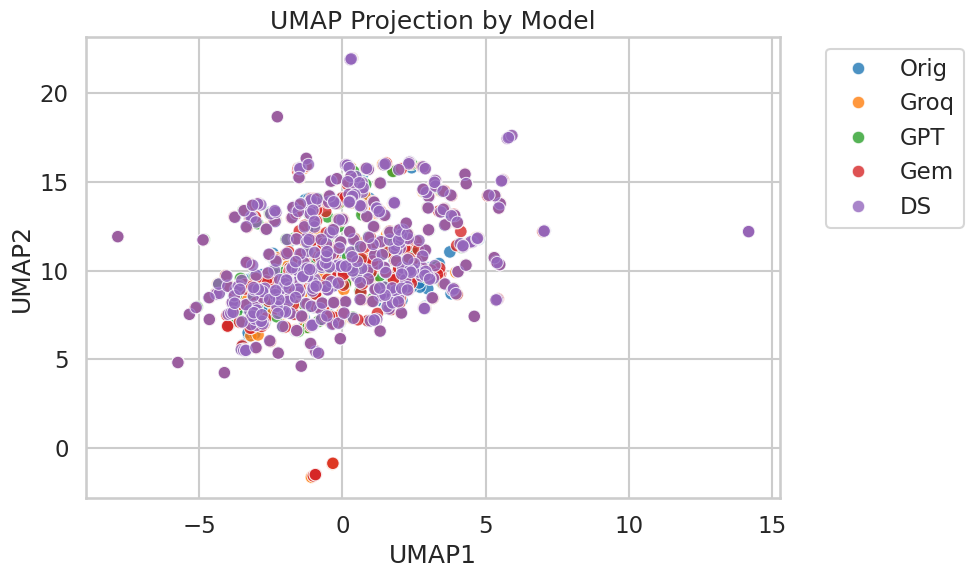

In [ ]:
umap_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'])
umap_df['model'] = df_embs['model'].values  # or 'batch' if preferred
# plot

plt.figure(figsize=(10, 6))
sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', hue='model', palette='tab10', alpha=0.8)
plt.title('UMAP Projection by Model')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()